<a href="https://colab.research.google.com/github/HooroBoy/PCVK_ganjil_2026/blob/dev/PCVK2_Prak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


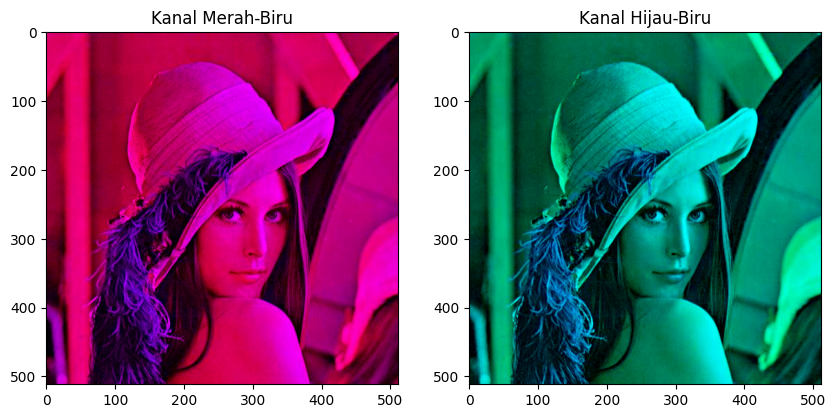

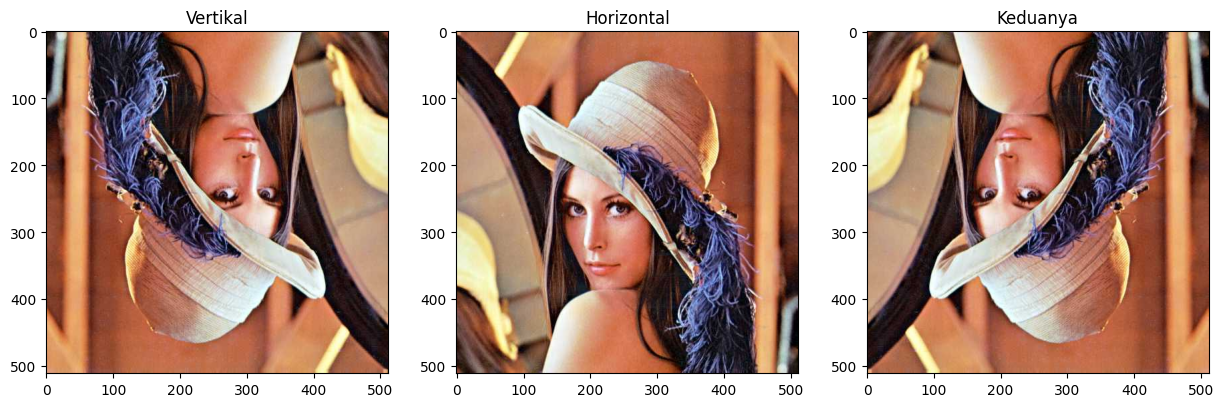

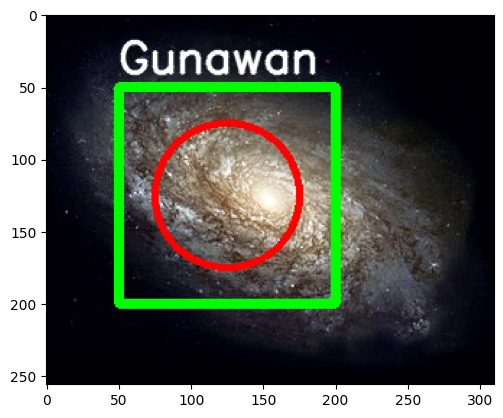

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolasi Kanal Warna
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0 # Nol-kan kanal Hijau

img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0 # Nol-kan kanal Merah

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rb); axes[0].set_title('Kanal Merah-Biru')
axes[1].imshow(img_gb); axes[1].set_title('Kanal Hijau-Biru')
plt.show()

# 2. Pencerminan Citra
flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_both = cv.flip(img_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(flip_v); axes[0].set_title('Vertikal')
axes[1].imshow(flip_h); axes[1].set_title('Horizontal')
axes[2].imshow(flip_both); axes[2].set_title('Keduanya')
plt.show()

# 3. Geometri pada Foto Aktivitas
img_act = cv.imread('/content/drive/MyDrive/PCVK/galaxy.jpg')
img_act = cv.cvtColor(img_act, cv.COLOR_BGR2RGB)

cv.rectangle(img_act, (50, 50), (200, 200), (0, 255, 0), 5)
cv.circle(img_act, (125, 125), 50, (255, 0, 0), 3)
cv.putText(img_act, 'Gunawan', (50, 40), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv.LINE_AA)
plt.imshow(img_act)
plt.show()

#Praktikum 2

In [4]:
# Studi Kasus 1: Panitia Kegiatan (Label Proporsional)
def label_panitia(img, text="Dokumentasi PCVK - 2026"):
    h, w = img.shape[:2]
    bar_height = h // 12
    img_out = img.copy()

    cv.rectangle(img_out, (0, h - bar_height), (w, h), (0, 0, 0), -1)

    font_scale = h / 800
    thickness = max(1, int(h / 400))
    text_y = h - (bar_height // 3)

    cv.putText(img_out, text, (20, text_y), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (255, 255, 255), thickness, cv.LINE_AA)
    return img_out

# Studi Kasus 2: Marketplace Thumbnail (Rasio Persegi)
def thumbnail_marketplace(img):
    h, w = img.shape[:2]
    max_dim = max(h, w)

    # Kanvas persegi warna putih
    canvas = np.full((max_dim, max_dim, 3), 255, dtype=np.uint8)

    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img

    font_scale = max_dim / 1000
    cv.putText(canvas, "BEKASWIT", (20, 50), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (0, 0, 255), 2, cv.LINE_AA)
    cv.putText(canvas, "Bekas Jadi Duwit", (20, 80), cv.FONT_HERSHEY_SIMPLEX,
               font_scale * 0.5, (50, 50, 50), 1, cv.LINE_AA)
    return canvas

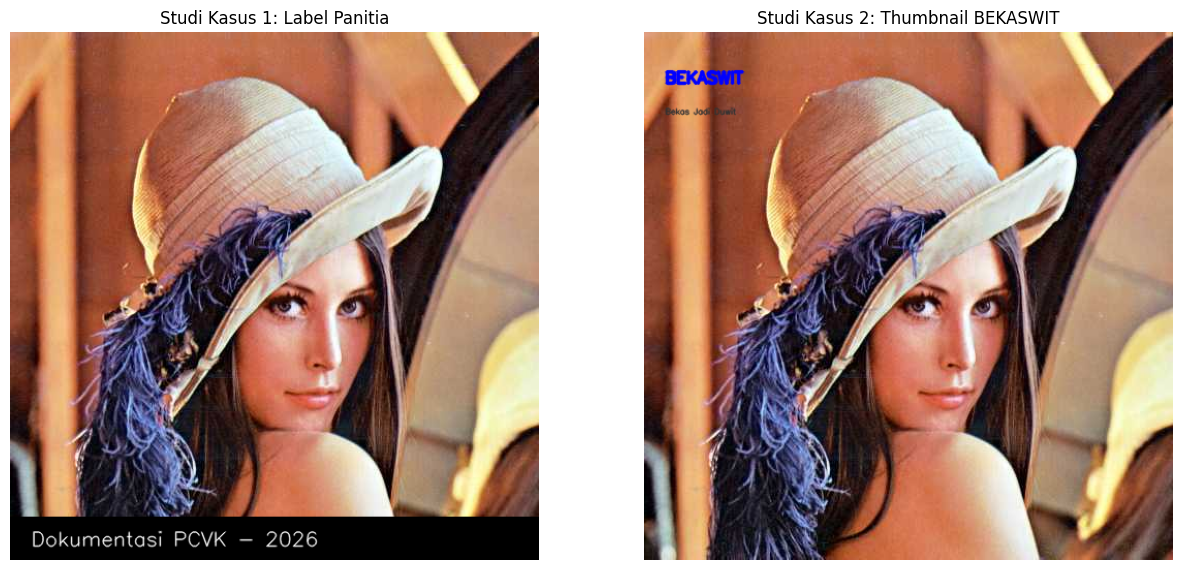

In [6]:
img_uji = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_uji_rgb = cv.cvtColor(img_uji, cv.COLOR_BGR2RGB)

hasil_panitia = label_panitia(img_uji_rgb)
hasil_bekaswit = thumbnail_marketplace(img_uji_rgb)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(hasil_panitia)
axes[0].set_title('Studi Kasus 1: Label Panitia')
axes[0].axis('off')

axes[1].imshow(hasil_bekaswit)
axes[1].set_title('Studi Kasus 2: Thumbnail BEKASWIT')
axes[1].axis('off')

plt.show()